# Retail Demand Forecasting

## 6. SARIMAX Forecasting

This stage develops a statistical time-series forecasting model using Seasonal AutoRegressive Integrated Moving Average with Exogenous Variables (SARIMAX).

The model is used to capture temporal dependence and recurring seasonal patterns while incorporating external explanatory variables.

SARIMAX performance will be evaluated against the baseline forecasting methods established in the previous stage.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 6.1 Load Forecasting Dataset

The feature-engineered dataset is loaded and prepared for statistical time-series modelling.

In [3]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "outputs/tables/forecasting_features.csv"

required_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
    "dcoilwtico"
]

series_summary_parts = []

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=required_columns,
    chunksize=200_000
):
    summary = (
        chunk
        .groupby(["store_nbr", "family"])["sales"]
        .agg(
            total_sales="sum",
            mean_sales="mean",
            observations="count"
        )
        .reset_index()
    )

    series_summary_parts.append(summary)

series_summary = (
    pd.concat(series_summary_parts)
    .groupby(["store_nbr", "family"])
    .agg(
        total_sales=("total_sales", "sum"),
        mean_sales=("mean_sales", "mean"),
        observations=("observations", "sum")
    )
    .reset_index()
)

series_summary = series_summary.sort_values(
    "total_sales",
    ascending=False
).reset_index(drop=True)

print(f"Number of store-family series: {len(series_summary):,}")

Number of store-family series: 1,782


In [4]:
series_summary.head(10)

,store_nbr,family,total_sales,mean_sales,observations
0,45,GROCERY I,"16,161,445.29","9,787.92",1656
1,44,GROCERY I,"16,158,827.04","9,769.24",1656
2,47,GROCERY I,"15,325,485.49","9,280.00",1656
3,46,GROCERY I,"14,168,008.00","8,585.59",1656
4,44,BEVERAGES,"13,292,328.00","8,068.11",1656
5,3,GROCERY I,"12,816,804.97","7,751.89",1656
6,48,GROCERY I,"12,684,045.11","7,676.18",1656
7,45,BEVERAGES,"11,281,045.00","6,860.75",1656
8,3,BEVERAGES,"11,253,680.00","6,834.34",1656
9,49,GROCERY I,"10,996,390.00","6,666.49",1656


In [5]:
selected_store = series_summary.iloc[0]["store_nbr"]
selected_family = series_summary.iloc[0]["family"]

print("Selected store:", selected_store)
print("Selected family:", selected_family)

Selected store: 45
Selected family: GROCERY I


## 6.2 Extract Representative Demand Series

The highest-volume store-product family combination is extracted from the feature-engineered dataset.

Processing is performed in chunks so that the full forecasting dataset does not need to be loaded into memory.

In [6]:
selected_parts = []

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=required_columns,
    chunksize=200_000
):
    selected = chunk[
        (chunk["store_nbr"] == selected_store) &
        (chunk["family"] == selected_family)
    ].copy()

    if not selected.empty:
        selected_parts.append(selected)

series = pd.concat(
    selected_parts,
    ignore_index=True
)

series["date"] = pd.to_datetime(series["date"])

series = (
    series
    .sort_values("date")
    .drop_duplicates(subset="date")
    .reset_index(drop=True)
)

print(f"Selected series shape: {series.shape}")
print(f"Start date: {series['date'].min()}")
print(f"End date: {series['date'].max()}")

Selected series shape: (1656, 6)
Start date: 2013-01-29 00:00:00
End date: 2017-08-15 00:00:00


## 6.3 Prepare the Demand Series

The selected store-product family series is prepared as a daily time series for SARIMAX modelling.

In [7]:
series = series.set_index("date")

series = series.asfreq("D")

print(f"Observations: {len(series):,}")
print(f"Start: {series.index.min()}")
print(f"End: {series.index.max()}")

Observations: 1,660
Start: 2013-01-29 00:00:00
End: 2017-08-15 00:00:00


In [8]:
series[
    ["sales", "onpromotion", "dcoilwtico"]
].isna().sum()

sales            4
onpromotion      4
dcoilwtico     515
dtype: int64

## 6.4 Demand Series Visualization

The selected store-product family is examined visually to identify long-term trends, recurring weekly patterns, and periods of unusually high or low demand before fitting the SARIMAX model.

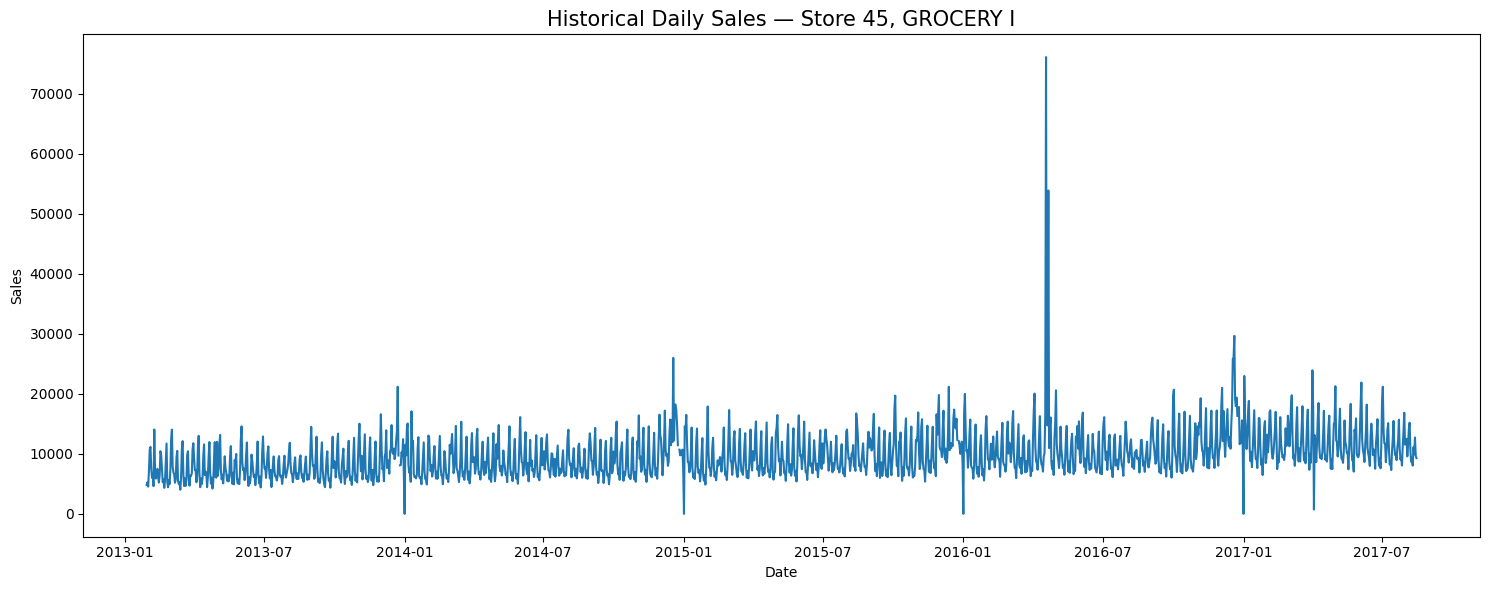

In [9]:
plt.figure(figsize=(15, 6))

plt.plot(
    series.index,
    series["sales"]
)

plt.title(
    f"Historical Daily Sales — Store {selected_store}, {selected_family}",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

## 6.5 Data Quality Check

Before statistical modelling, the selected time series is checked for missing observations and missing values in the variables used by the forecasting model.

In [10]:
model_columns = [
    "sales",
    "onpromotion",
    "dcoilwtico"
]

missing_summary = (
    series[model_columns]
    .isna()
    .sum()
    .to_frame("missing_values")
)

missing_summary

,missing_values
sales,4
onpromotion,4
dcoilwtico,515


In [11]:
print("Total missing sales:", series["sales"].isna().sum())
print("Total missing observations:", series.index.isna().sum())

Total missing sales: 4
Total missing observations: 0


## 6.6 Weekly Seasonal Pattern

Weekly demand patterns are examined to determine whether sales systematically differ across days of the week.

A seven-day seasonal period is used in the SARIMAX specification.

In [12]:
weekly_pattern = (
    series
    .assign(day_of_week=series.index.day_name())
    .groupby("day_of_week")["sales"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern = weekly_pattern.reindex(day_order)

weekly_pattern

day_of_week
Monday       9,684.36
Tuesday      8,050.24
Wednesday    8,383.90
Thursday     7,111.85
Friday       8,975.81
Saturday    12,152.64
Sunday      13,961.15
Name: sales, dtype: float64

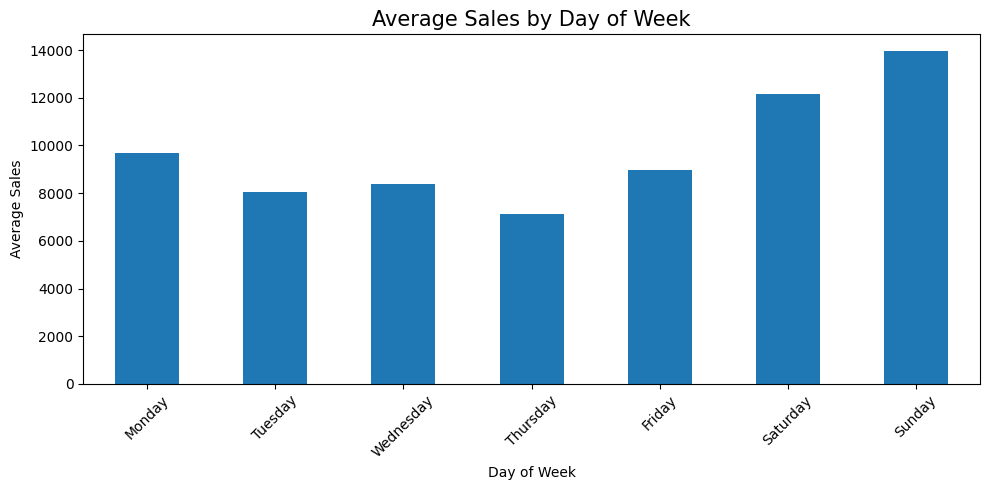

In [13]:
plt.figure(figsize=(10, 5))

weekly_pattern.plot(kind="bar")

plt.title("Average Sales by Day of Week", fontsize=15)
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6.7 Chronological Train-Test Split

The final 30 days of the selected demand series are reserved as an out-of-sample test period.

The model is trained exclusively on observations occurring before the test period, preserving the chronological structure of the forecasting problem.

In [14]:
TEST_DAYS = 30

sarimax_train = series.iloc[:-TEST_DAYS].copy()
sarimax_test = series.iloc[-TEST_DAYS:].copy()

print(
    "Training period:",
    sarimax_train.index.min(),
    "to",
    sarimax_train.index.max()
)

print(
    "Test period:",
    sarimax_test.index.min(),
    "to",
    sarimax_test.index.max()
)

print("\nTraining observations:", len(sarimax_train))
print("Test observations:", len(sarimax_test))

Training period: 2013-01-29 00:00:00 to 2017-07-16 00:00:00
Test period: 2017-07-17 00:00:00 to 2017-08-15 00:00:00

Training observations: 1630
Test observations: 30


## 6.8 Exogenous Variables

Promotional activity and external oil prices are incorporated as exogenous variables where available.

These variables provide additional information beyond the historical sales sequence and allow the SARIMAX model to account for external demand drivers.

In [15]:
exog_columns = []

if "onpromotion" in series.columns:
    exog_columns.append("onpromotion")

if "dcoilwtico" in series.columns:
    exog_columns.append("dcoilwtico")

print("Exogenous variables:", exog_columns)

Exogenous variables: ['onpromotion', 'dcoilwtico']


In [16]:
if exog_columns:
    train_exog = sarimax_train[exog_columns].copy()
    test_exog = sarimax_test[exog_columns].copy()

    train_exog = train_exog.ffill().bfill()
    test_exog = test_exog.ffill().bfill()

else:
    train_exog = None
    test_exog = None

In [17]:
if train_exog is not None:
    print(train_exog.head())
    print("\nMissing values:")
    print(train_exog.isna().sum())

            onpromotion  dcoilwtico
date                               
2013-01-29         0.00       97.62
2013-01-30         0.00       97.98
2013-01-31         0.00       97.65
2013-02-01         0.00       97.46
2013-02-02         0.00       97.46

Missing values:
onpromotion    0
dcoilwtico     0
dtype: int64


## 6.9 SARIMAX Model

A SARIMAX model is fitted to the selected demand series.

The model incorporates:

- Autoregressive behaviour
- Differencing
- Moving-average behaviour
- Weekly seasonality
- Promotional activity
- External oil prices

The initial specification uses a seven-day seasonal period to represent weekly retail demand patterns.

In [18]:
sarimax_model = SARIMAX(
    sarimax_train["sales"],
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(
    disp=False
)

print(sarimax_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1630
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -15214.036
Date:                           Sun, 23 Aug 2026   AIC                          30442.072
Time:                                   11:19:12   BIC                          30479.773
Sample:                               01-29-2013   HQIC                         30456.066
                                    - 07-16-2017                                         
Covariance Type:                             opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
onpromotion    70.3094      6.787     10.359      0.000      57.007      83.612
dcoilwtico     67.9688     62.368      1

In [19]:
print(sarimax_result.aic)
print(sarimax_result.bic)

30442.072413112994
30479.77337065987


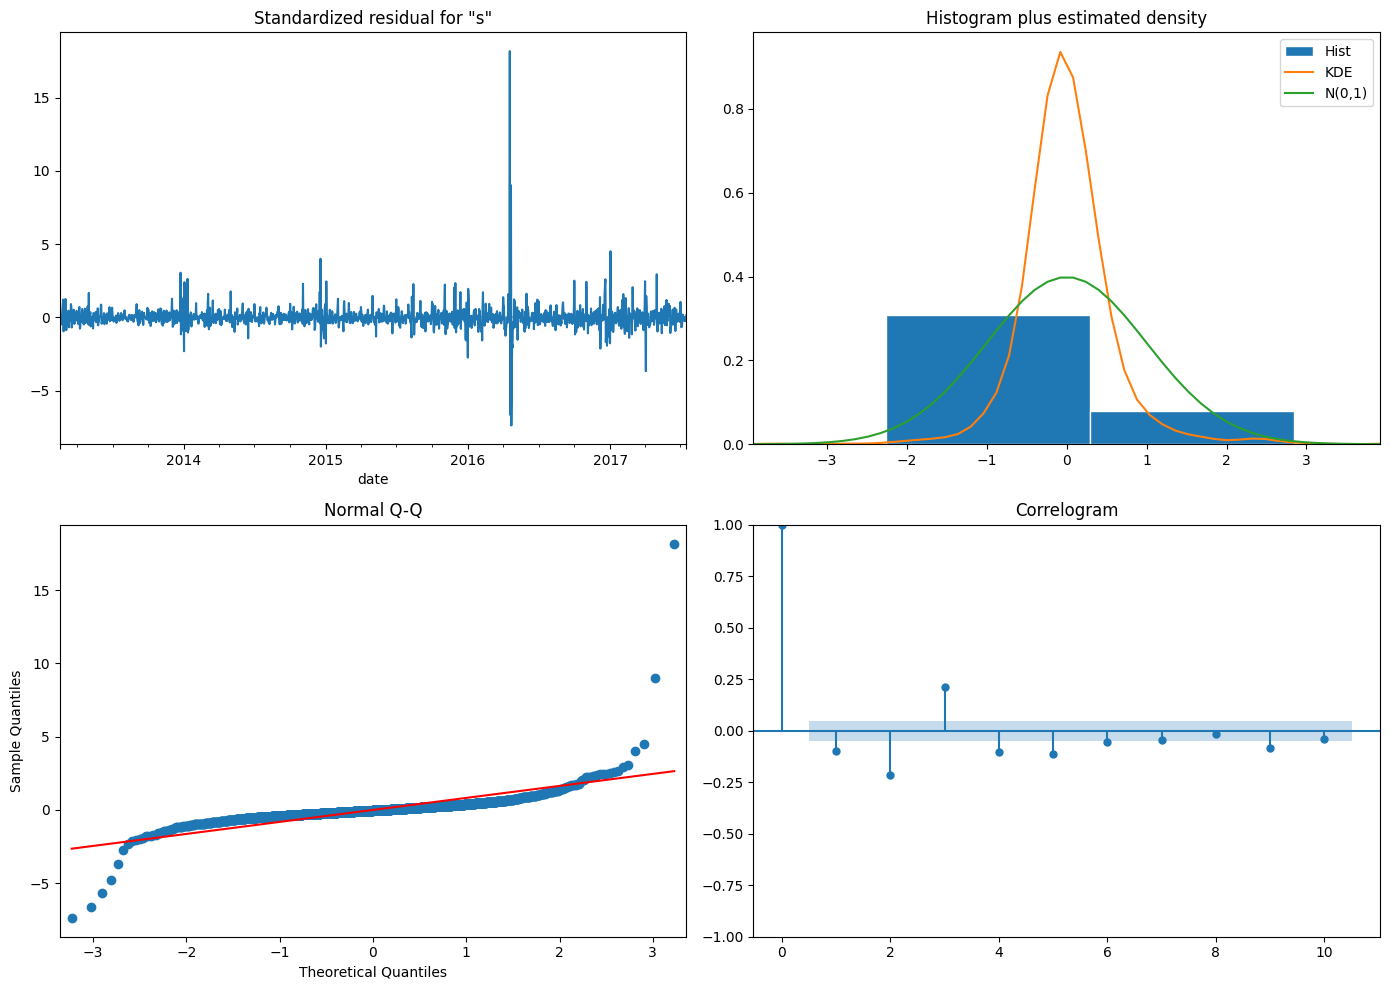

In [20]:
sarimax_result.plot_diagnostics(
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

## 6.10 Out-of-Sample Forecast

The fitted SARIMAX model is used to forecast demand across the 30-day holdout period.

Forecasts are generated using the corresponding exogenous variables from the test period.

In [21]:
sarimax_forecast = sarimax_result.get_forecast(
    steps=TEST_DAYS,
    exog=test_exog
)

forecast_mean = sarimax_forecast.predicted_mean

forecast_ci = sarimax_forecast.conf_int()

forecast_mean.head()

2017-07-17   10,427.80
2017-07-18    8,907.92
2017-07-19    9,382.85
2017-07-20    8,146.99
2017-07-21   10,973.92
Freq: D, Name: predicted_mean, dtype: float64

## 6.11 SARIMAX Forecast Evaluation

The SARIMAX predictions are evaluated against the actual observations in the holdout period using MAE, RMSE, and MAPE.

These metrics allow direct comparison with the baseline forecasting models.

In [22]:
actual = sarimax_test["sales"]

sarimax_mae = mean_absolute_error(
    actual,
    forecast_mean
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        actual,
        forecast_mean
    )
)

non_zero = actual != 0

sarimax_mape = (
    np.mean(
        np.abs(
            (actual[non_zero] - forecast_mean[non_zero])
            / actual[non_zero]
        )
    ) * 100
)

print(f"MAE: {sarimax_mae:,.2f}")
print(f"RMSE: {sarimax_rmse:,.2f}")
print(f"MAPE: {sarimax_mape:.2f}%")

MAE: 1,889.02
RMSE: 2,420.27
MAPE: 17.45%


## 6.12 SARIMAX Forecast Visualization

The predicted demand is compared with actual demand during the holdout period.

The confidence interval provides an indication of forecast uncertainty.

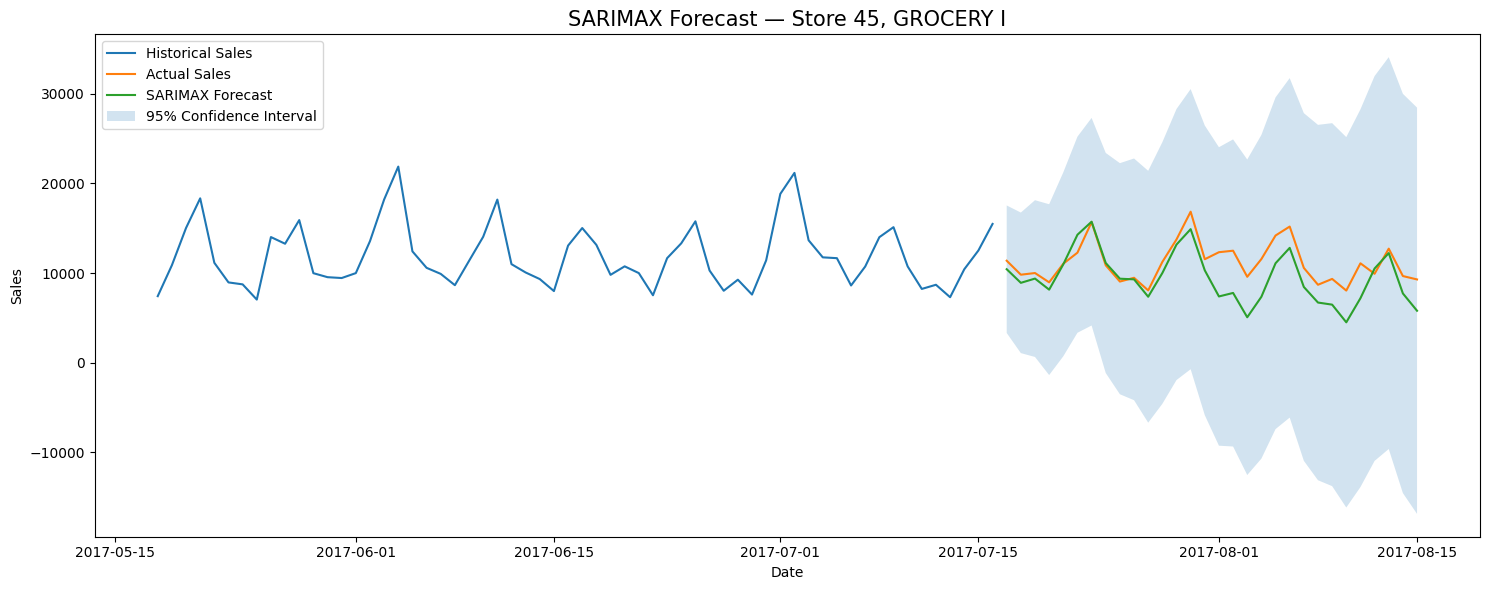

In [23]:
plt.figure(figsize=(15, 6))

plt.plot(
    sarimax_train.index[-60:],
    sarimax_train["sales"].iloc[-60:],
    label="Historical Sales"
)

plt.plot(
    sarimax_test.index,
    actual,
    label="Actual Sales"
)

plt.plot(
    sarimax_test.index,
    forecast_mean,
    label="SARIMAX Forecast"
)

plt.fill_between(
    sarimax_test.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    f"SARIMAX Forecast — Store {selected_store}, {selected_family}",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

## 6.13 Comparison with Seasonal Naive

SARIMAX performance is compared against the seasonal naive benchmark over the same forecasting period.

This comparison determines whether the statistical model provides a measurable improvement over a simple weekly seasonal assumption.

In [24]:
sarimax_test["seasonal_naive"] = (
    series["sales"]
    .shift(7)
    .loc[sarimax_test.index]
)

In [25]:
baseline_mae = mean_absolute_error(
    sarimax_test["sales"],
    sarimax_test["seasonal_naive"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        sarimax_test["sales"],
        sarimax_test["seasonal_naive"]
    )
)

print(f"Seasonal Naive MAE: {baseline_mae:,.2f}")
print(f"SARIMAX MAE: {sarimax_mae:,.2f}")

print()

print(f"Seasonal Naive RMSE: {baseline_rmse:,.2f}")
print(f"SARIMAX RMSE: {sarimax_rmse:,.2f}")

Seasonal Naive MAE: 1,357.77
SARIMAX MAE: 1,889.02

Seasonal Naive RMSE: 1,744.01
SARIMAX RMSE: 2,420.27


In [26]:
mae_improvement = (
    (baseline_mae - sarimax_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - sarimax_rmse)
    / baseline_rmse
) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement: -39.13%
RMSE improvement: -38.78%


## 6.14 Statistical Model Comparison

The SARIMAX model is compared with the seasonal naive benchmark using identical evaluation data and performance metrics.

In [28]:
sarimax_results = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse
    },
    {
        "Model": "SARIMAX",
        "MAE": sarimax_mae,
        "RMSE": sarimax_rmse
    }
])

sarimax_results

,Model,MAE,RMSE
0,Seasonal Naive,"1,357.77","1,744.01"
1,SARIMAX,"1,889.02","2,420.27"


## 6.15 Export SARIMAX Results

The statistical forecasting results and out-of-sample predictions are exported for use in the final model comparison.

In [29]:
os.makedirs(
    "outputs/tables",
    exist_ok=True
)

sarimax_results.to_csv(
    "outputs/tables/sarimax_results.csv",
    index=False
)

forecast_output = pd.DataFrame({
    "date": sarimax_test.index,
    "actual_sales": actual.values,
    "sarimax_forecast": forecast_mean.values
})

forecast_output.to_csv(
    "outputs/tables/sarimax_forecast.csv",
    index=False
)

print("SARIMAX results exported successfully.")

SARIMAX results exported successfully.


## 6.16 SARIMAX Summary

A seasonal SARIMAX model was developed to capture temporal dependence and weekly demand patterns while incorporating available external variables.

The model was evaluated using a chronological holdout period and compared against the seasonal naive benchmark.

The results establish a statistical forecasting benchmark for the subsequent machine-learning approach.

The next stage will develop an XGBoost forecasting model using the engineered lag, rolling, seasonal, promotional, and external features.

In [30]:
print("Selected store:", selected_store)
print("Selected family:", selected_family)

Selected store: 45
Selected family: GROCERY I
